# построение моделей для предсказания стоимости автомобилей

## 0. ссылка на датасет
https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho?select=Car+details+v3.csv

## 1. Постановка задачи
**Цель проекта:** Построить модель машинного обучения для прогнозирования стоимости автомобиля (`selling_price`) на основе его технических характеристик, состояния и истории владения.

**Тип задачи:** Регрессия.

**Целевая переменная (Target):** `selling_price`. К ней будет применено логарифмирование для стабилизации дисперсии и приведения распределения к нормальному виду.

**Метрики качества:**
* **MAPE (Mean Absolute Percentage Error)** — средняя абсолютная процентная ошибка. Показывает, на сколько процентов в среднем ошибается модель относительно реальной цены.
* **RMSE (Root Mean Squared Error)** — корень из средней квадратичной ошибки, чувствителен к крупным выбросам.
* **R² (Коэффициент детерминации)** — доля дисперсии зависимой переменной, объясняемая моделью.

**Выбранные модели:**
1. **Ridge Регрессия** — линейная модель с L2-регуляризацией в качестве надежного Baseline.
2. **Random Forest Regressor** — мощный ансамблевый метод на основе деревьев решений для улавливания нелинейных зависимостей.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42  # Фиксируем seed для полной воспроизводимости

import warnings
warnings.filterwarnings('ignore')

# Загружаем данные
try:
    df = pd.read_csv('Car_details_v3.csv')
    print(f"Успешно загружено! Размер датасета: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print("Файл Car_details_v3.csv не найден. Поместите его в рабочую папку ноутбука.")

Успешно загружено! Размер датасета: (8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [11]:
print("=== Информация о датасете ===")
df.info()
print("\n=== Проверка пропущенных значений ===")
print(df.isnull().sum())

=== Информация о датасете ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB

=== Проверка пропущенных значений ===
name               0
year               0
selling_price      0
km_driven          0
fuel            

## 2. Очистка данных и Feature Engineering

В исходных данных признаки `mileage`, `engine` и `max_power` содержат текстовые приставки единиц измерения (например, "23.4 kmpl", "1248 CC", "74 bhp"). Извлечем из них числовые значения с помощью регулярных выражений.

Из признака `name` извлечем марку автомобиля (первое слово)

в признаке `torque` встречаюются различные единицы измерения, обоззначения  не стандартизированы, поэтому не будем учитывать этот его

после удаления строк с пропущенными ззначениями, обьем выборки снизится с 8128 до 7906, поэтому не будем пытаться придумать, чем заполнить пропуски

In [2]:
df_cleaned = df.copy() if 'df' in locals() else pd.DataFrame()

if not df_cleaned.empty:
    # Функция для извлечения первого числового значения из строки
    def extract_numeric(text):
        if pd.isna(text):
            return np.nan
        nums = re.findall(r"[-+]?(?:\d*\.*\d+)", str(text))
        return float(nums[0]) if nums else np.nan

    # Применяем очистку к колонкам
    df_cleaned['mileage'] = df_cleaned['mileage'].apply(extract_numeric)
    df_cleaned['engine'] = df_cleaned['engine'].apply(extract_numeric)

    # Обработка max_power (убираем строки вида ' bhp')
    df_cleaned['max_power'] = df_cleaned['max_power'].replace(' bhp', np.nan)
    df_cleaned['max_power'] = df_cleaned['max_power'].apply(extract_numeric)

    # Извлечение марки автомобиля (Brand)
    df_cleaned['brand'] = df_cleaned['name'].apply(lambda x: x.split(' ')[0])

    # Удаление исходного имени и столбца torque
    df_cleaned.drop(columns=['name', 'torque'], inplace=True)

    # Удаление строк с пропущенными значениями для чистоты эксперимента
    df_cleaned.dropna(inplace=True)

    print(f"Размер датасета после очистки: {df_cleaned.shape}")
    print(df_cleaned.info())
else:
    print("Пропустите эту ячейку, пока датасет не будет загружен.")

Размер датасета после очистки: (7906, 12)
<class 'pandas.core.frame.DataFrame'>
Index: 7906 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           7906 non-null   int64  
 1   selling_price  7906 non-null   int64  
 2   km_driven      7906 non-null   int64  
 3   fuel           7906 non-null   object 
 4   seller_type    7906 non-null   object 
 5   transmission   7906 non-null   object 
 6   owner          7906 non-null   object 
 7   mileage        7906 non-null   float64
 8   engine         7906 non-null   float64
 9   max_power      7906 non-null   float64
 10  seats          7906 non-null   float64
 11  brand          7906 non-null   object 
dtypes: float64(4), int64(3), object(5)
memory usage: 803.0+ KB
None


## 3. Разведочный анализ данных (EDA)

Построим комплексную визуализацию для изучения распределения целевой переменной, влияния года выпуска и типа топлива на стоимость, а также построим корреляционную матрицу.

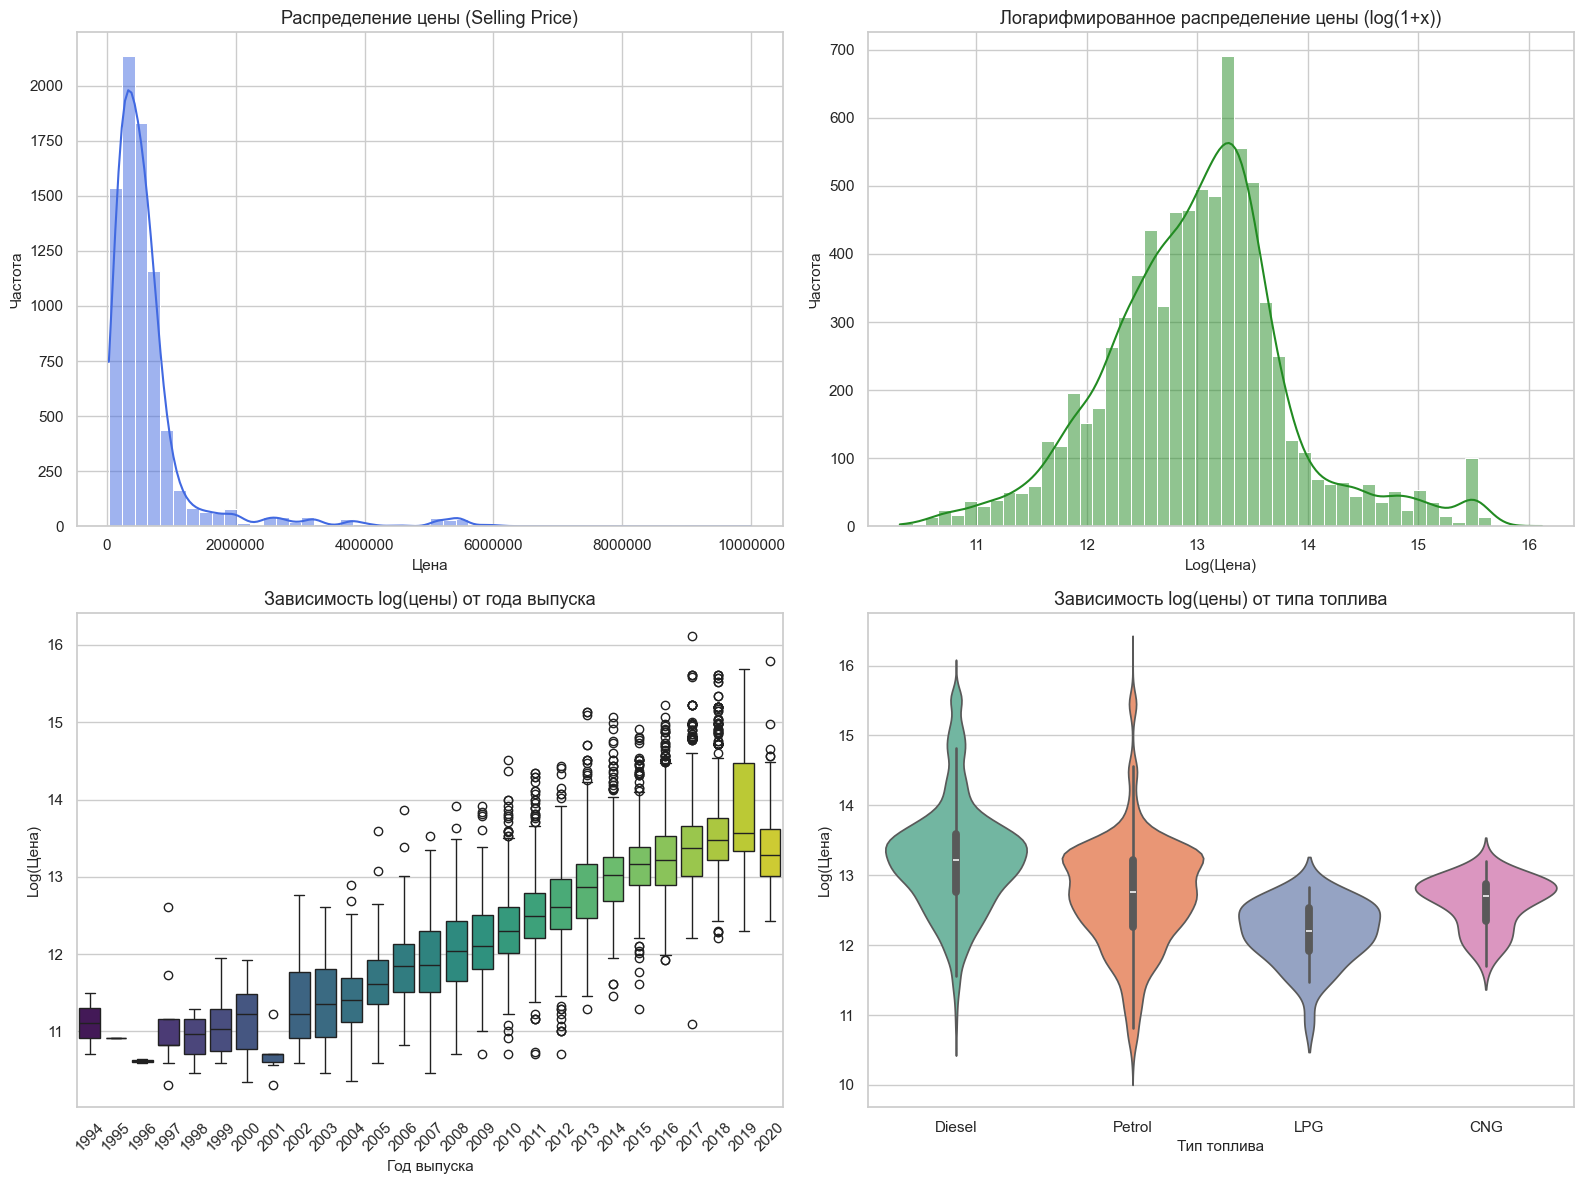

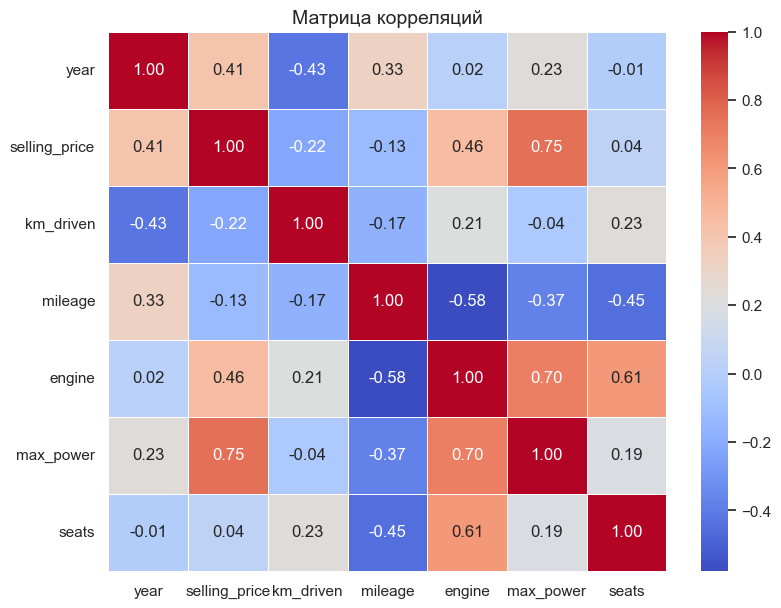

In [10]:
if not df_cleaned.empty:
    plt.figure(figsize=(16, 12))

    #распределение исходной цены автомобиля
    plt.subplot(2, 2, 1)
    sns.histplot(df_cleaned['selling_price'], bins=50, kde=True, color='royalblue')
    plt.title('Распределение цены (Selling Price)', fontsize=13)
    plt.xlabel('Цена', fontsize=11)
    plt.ylabel('Частота', fontsize=11)
    plt.ticklabel_format(style='plain', axis='x')

    # распределение логарифмированной цены
    plt.subplot(2, 2, 2)
    sns.histplot(np.log1p(df_cleaned['selling_price']), bins=50, kde=True, color='forestgreen')
    plt.title('Логарифмированное распределение цены (log(1+x))', fontsize=13)
    plt.xlabel('Log(Цена)', fontsize=11)
    plt.ylabel('Частота', fontsize=11)

    #зависимость цены от года выпуска
    plt.subplot(2, 2, 3)
    sns.boxplot(x='year', y=np.log1p(df_cleaned['selling_price']), data=df_cleaned, palette='viridis')
    plt.title('Зависимость log(цены) от года выпуска', fontsize=13)
    plt.xlabel('Год выпуска', fontsize=11)
    plt.ylabel('Log(Цена)', fontsize=11)
    plt.xticks(rotation=45)

    #зависимость цены от типа топлива
    plt.subplot(2, 2, 4)
    sns.violinplot(x='fuel', y=np.log1p(df_cleaned['selling_price']), data=df_cleaned, palette='Set2')
    plt.title('Зависимость log(цены) от типа топлива', fontsize=13)
    plt.xlabel('Тип топлива', fontsize=11)
    plt.ylabel('Log(Цена)', fontsize=11)

    plt.tight_layout()
    plt.show()

    #корреляционная матрица
    plt.figure(figsize=(9, 7))
    numeric_cols = ['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
    sns.heatmap(df_cleaned[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Матрица корреляций', fontsize=14)
    plt.show()
else:
    print("Нет данных для визуализации.")

### Выводы по результатам EDA:
1. **Целевая переменная:** цена сильно смещена в право. Логарифмирование исправляет асимметрию, приближая распределение к нормальному.
2. **Зависимости:** Более новые автомобили предсказуемо стоят дороже. Дизельные и бензиновые машины составляют основу рынка, при этом дизельные авто имеют чуть более высокий медианный чек.
3. **Корреляции:** Сильнее всего на цену влияют мощность двигателя (`max_power`, 0.75).  Год выпуска (0.41) и объём (`engine`, 0.46).  также имеюют сильную прямую связь.

## 4. Подготовка данных и Preprocessing

Разделим признаки по типам. Для числовых применим стандартизацию (`StandardScaler`), а для категориальных — кодирование (`OneHotEncoder`). Объединим их с помощью `ColumnTransformer`.

In [7]:
if not df_cleaned.empty:
    # Разделение признаков и логарифмированного таргета
    X = df_cleaned.drop(columns=['selling_price'])
    y = np.log1p(df_cleaned['selling_price'])

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=RANDOM_STATE)

    categorical_features = ['fuel', 'seller_type', 'transmission', 'owner', 'brand']
    numeric_features = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

    # Сборка предобработчика
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ])

    print(f"Обучающая выборка: {X_train.shape}")
    print(f"Тестовая выборка: {X_test.shape}")
else:
    print("Данные не подготовлены.")

Обучающая выборка: (6720, 11)
Тестовая выборка: (1186, 11)


## 5. Обучение моделей и кросс-валидация (GridSearchCV)

Создадим функцию оценки, переводящую логарифм цен обратно в реальный масштаб через `expm1`, чтобы рассчитывать метрику **MAPE** в процентах.

In [8]:
def evaluate_regression_model(model, X_test, y_test, model_name):
    # Предсказания в логарифмическом масштабе
    y_pred_log = model.predict(X_test)
    
    # Возврат в оригинальный масштаб
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)
    
    # считаем метрики
    mape = mean_absolute_percentage_error(y_test_real, y_pred_real) * 100
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    r2 = r2_score(y_test_real, y_pred_real)
    
    print(f"=== Результаты для {model_name} ===")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"RMSE: {rmse:,.2f}\n")
    return y_test_real, y_pred_real

if not df_cleaned.empty:
    # 1. Линейная модель (Ridge Регрессия)
    ridge_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', Ridge(random_state=RANDOM_STATE))
    ])
    
    ridge_param_grid = {'regressor__alpha': [0.1, 1.0, 10.0, 100.0]}
    grid_ridge = GridSearchCV(ridge_pipeline, ridge_param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_ridge.fit(X_train, y_train)
    print(f"Лучшие параметры Ridge: {grid_ridge.best_params_}")
    _ = evaluate_regression_model(grid_ridge.best_estimator_, X_test, y_test, "Ridge Regression")

    # 2. Нелинейная модель (Random Forest Regressor)
    rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
    ])
    
    rf_param_grid = {
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [15, 25, None],
        'regressor__min_samples_split': [2, 5]
    }
    grid_rf = GridSearchCV(rf_pipeline, rf_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_rf.fit(X_train, y_train)
    print(f"Лучшие параметры Random Forest: {grid_rf.best_params_}")
    y_test_real, y_pred_rf = evaluate_regression_model(grid_rf.best_estimator_, X_test, y_test, "Random Forest")
else:
    print("Ошибка при запуске обучения.")

Лучшие параметры Ridge: {'regressor__alpha': 0.1}
=== Результаты для Ridge Regression ===
R² Score: 0.9332
MAPE: 20.43%
RMSE: 222,294.30

Лучшие параметры Random Forest: {'regressor__max_depth': 25, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
=== Результаты для Random Forest ===
R² Score: 0.9831
MAPE: 13.95%
RMSE: 111,853.41



## 6. Визуализация результатов предсказаний

Построим диаграмму сопоставления предсказанных значений с истинными значениями тестовой выборки для лучшей модели.

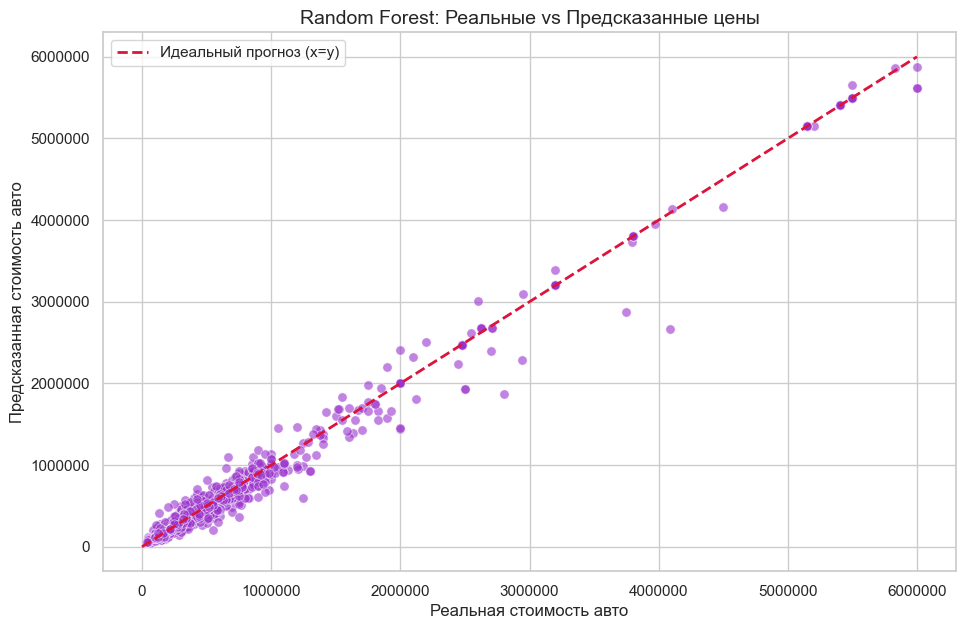

In [9]:
if 'y_pred_rf' in locals():
    plt.figure(figsize=(11, 7))
    sns.scatterplot(x=y_test_real, y=y_pred_rf, alpha=0.6, color='darkorchid', edgecolor='w', s=45)
    
    max_val = max(y_test_real.max(), y_pred_rf.max())
    plt.plot([0, max_val], [0, max_val], linestyle='--', color='crimson', linewidth=2, label='Идеальный прогноз (x=y)')
    
    plt.title('Random Forest: Реальные vs Предсказанные цены', fontsize=14)
    plt.xlabel('Реальная стоимость авто', fontsize=12)
    plt.ylabel('Предсказанная стоимость авто', fontsize=12)
    plt.ticklabel_format(style='plain', axis='both')
    plt.legend(fontsize=11)
    plt.show()
else:
    print("Сначала обучите модели.")

## Сравнение метрик 
**R² (Коэффициент детерминации):**

* **Random Forest:** 0.9831 (объясняет ~98.3% разброса цен).

 * **Ridge: 0.9332** * (объясняет ~93.3% разброса цен).

**выводы:** Обе модели показали отличные результаты, случайный лес сработал практически идеально. Это говорит о том, что в данных о машинах много нелинейных зависимостей (например, влияние возраста на цену не является строгой прямой линией, а определенные марки авто в сочетании с мощным двигателем дают непропорциональный прирост к цене). Линейная модель эти тонкости улавливает хуже.

**MAPE (Средняя абсолютная процентная ошибка)**:

* Random Forest: 13.95%

* Ridge: 20.43%

**выводы:** Это самая понятная для бизнеса метрика. В среднем случайный лес ошибается при оценке стоимости автомобиля всего на 14%, тогда как Ridge —  на 20%. Для вторичного рынка автомобилей, где цена сильно зависит от скрытых дефектов, 14% — выглядит рабочим показателем точности.

**RMSE (Корень из среднеквадратичной ошибки):**

* Random Forest: 111,853.41

* Ridge: 222,294.30

**выводы:** RMSE Случайного леса ровно в два раза ниже. Поскольку эта метрика квадратично штрафует за крупные ошибки, такой разрыв означает, что линейная модель довольно часто допускает серьезные промахи (сильно недооценивает дорогие премиальные автомобили или переоценивает старый хлам), в то время как лес делает прогнозы стабильнее.

## Анализ подобранных гиперпараметров
* **Ridge Regression (alpha: 0.1):**

Модель выбрала слабую L2-регуляризацию (альфа близка к нулю). Это означает, что мультиколлинеарность (сильная взаимозависимость признаков) не стала критичной проблемой, и модели не пришлось агрессивно занулять или сжимать веса признаков для борьбы с переобучением.

* **Random Forest (n_estimators: 200, max_depth: 25, min_samples_split: 5):**

* n_estimators = 200: Достаточно большое количество деревьев помогло усреднить прогнозы, снизить дисперсию и сделать модель устойчивой к шуму в данных.

* max_depth = 25: Деревья получились довольно глубокими. Это доказывает, что для точного предсказания цены алгоритму потребовалось выстроить сложную многоуровневую логику (например: "Если год > 2017, И бренд = Maruti, И топливо = Дизель, И пробег < 50 000...").

* min_samples_split = 5: Небольшое ограничение на минимальное количество объектов для разделения узла. Это выступило хорошим сдерживающим фактором, чтобы глубокие деревья не начали запоминать конкретные единичные машины (не переобучились), а всё же обобщали паттерны.